In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

main DataFrame

In [102]:
df = pd.DataFrame({
    'Transaction_ID': range(101, 111),
    'Date': ['2023-01-01', '2023-01-02', '2023-01-02', np.nan, '2023-01-04',
             '2023-01-05', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08'],
    'Product_ID': [1, 2, 1, 3, 2, 1, 3, 2, 4, 1],
    'Customer_ID': [501, 502, 501, 504, 502, 505, 504, 502, 508, 501],
    'Quantity': [2, 1, np.nan, 5, 2, 1, 3, np.nan, 1, 4],
    'Price': [20.0, 50.0, 20.0, 15.0, 50.0, 20.0, 15.0, 50.0, 100.0, 20.0]
})

In [103]:
prod= pd.DataFrame({
    'Product_ID': [1, 2, 3, 4],
    'Category': ['Electronics', 'Clothing', 'Home', 'Electronics'],
    'Cost': [12, 30, 8, 70]
})

In [104]:
cust = pd.DataFrame({
    'Customer_ID': [501, 502, 504, 505],
    'Country': ['USA', 'usa', 'UK', 'United Kingdom']
})

DATA CLEANING


convert date from str to datetime format

In [105]:
df['Date']=pd.to_datetime(df['Date'])

handling missing data

In [106]:
df['Date']=df['Date'].ffill()
df

,Transaction_ID,Date,Product_ID,Customer_ID,Quantity,Price
0,101,2023-01-01,1,501,2.0,20.0
1,102,2023-01-02,2,502,1.0,50.0
2,103,2023-01-02,1,501,NaN,20.0
3,104,2023-01-02,3,504,5.0,15.0
4,105,2023-01-04,2,502,2.0,50.0
5,106,2023-01-05,1,505,1.0,20.0
6,107,2023-01-05,3,504,3.0,15.0
7,108,2023-01-06,2,502,NaN,50.0
8,109,2023-01-07,4,508,1.0,100.0
9,110,2023-01-08,1,501,4.0,20.0


In [107]:
df = df.ffill()
df

,Transaction_ID,Date,Product_ID,Customer_ID,Quantity,Price
0,101,2023-01-01,1,501,2.0,20.0
1,102,2023-01-02,2,502,1.0,50.0
2,103,2023-01-02,1,501,1.0,20.0
3,104,2023-01-02,3,504,5.0,15.0
4,105,2023-01-04,2,502,2.0,50.0
5,106,2023-01-05,1,505,1.0,20.0
6,107,2023-01-05,3,504,3.0,15.0
7,108,2023-01-06,2,502,3.0,50.0
8,109,2023-01-07,4,508,1.0,100.0
9,110,2023-01-08,1,501,4.0,20.0


In [108]:
country_map = {'usa': 'USA', 'United Kingdom': 'UK'}
cust['Country'] = cust['Country'].replace(country_map)

MERGING

In [109]:
new_df = pd.merge(df, prod, on='Product_ID', how='inner')
final_df = pd.merge(new_df, cust , on='Customer_ID', how='left')

In [110]:
final_df

,Transaction_ID,Date,Product_ID,Customer_ID,Quantity,Price,Category,Cost,Country
0,101,2023-01-01,1,501,2.0,20.0,Electronics,12,USA
1,102,2023-01-02,2,502,1.0,50.0,Clothing,30,USA
2,103,2023-01-02,1,501,1.0,20.0,Electronics,12,USA
3,104,2023-01-02,3,504,5.0,15.0,Home,8,UK
4,105,2023-01-04,2,502,2.0,50.0,Clothing,30,USA
5,106,2023-01-05,1,505,1.0,20.0,Electronics,12,UK
6,107,2023-01-05,3,504,3.0,15.0,Home,8,UK
7,108,2023-01-06,2,502,3.0,50.0,Clothing,30,USA
8,109,2023-01-07,4,508,1.0,100.0,Electronics,70,NaN
9,110,2023-01-08,1,501,4.0,20.0,Electronics,12,USA


In [111]:
final_df['Total_profit']=(final_df['Price']-final_df['Cost']) * final_df['Quantity']

In [112]:
report = final_df.groupby(['Country','Category'])['Total_profit'].sum().reset_index()

In [113]:
print(final_df['Total_profit'].describe())

count    10.000000
mean     27.000000
std      15.930404
min       8.000000
25%      17.000000
50%      25.500000
75%      34.250000
max      60.000000
Name: Total_profit, dtype: float64


The Grouped Bar Chart (Comparing Categories)

In [114]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

(array([0, 1]), [Text(0, 0, 'UK'), Text(1, 0, 'USA')])

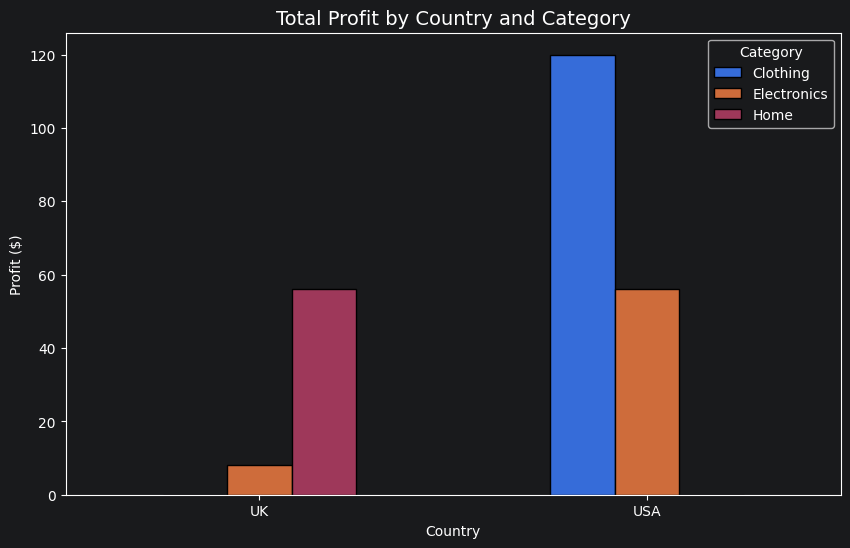

In [115]:
pivot_report= report.pivot(index='Country',columns='Category',values='Total_profit')
pivot_report.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Total Profit by Country and Category', fontsize=14)
plt.ylabel('Profit ($)')
plt.xlabel('Country')
plt.xticks(rotation=0)

The Line Plot (Time-Series Trends)

In [116]:
daily_trend = final_df.groupby('Date')['Total_profit'].sum()

Text(0, 0.5, 'Total Profit ($)')

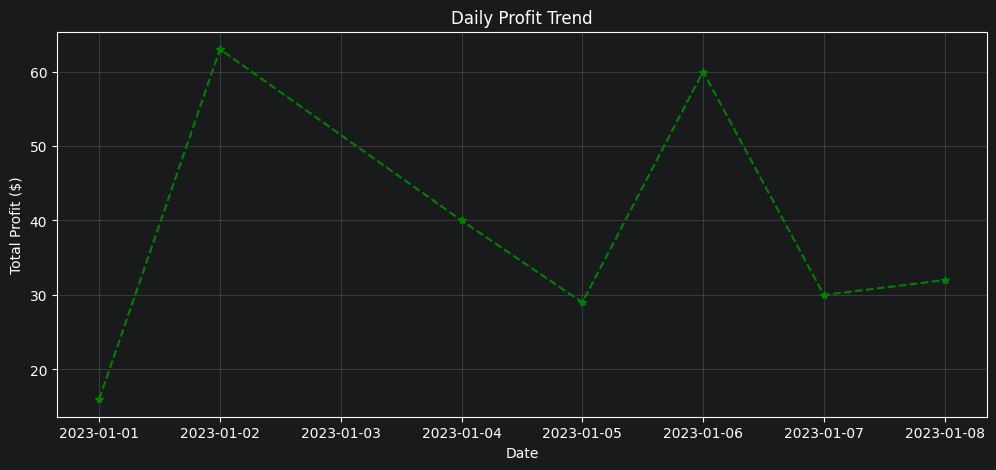

In [117]:
plt.figure(figsize=(12, 5))
plt.plot(daily_trend.index,daily_trend.values,'--g*')
plt.grid(True, alpha=0.3)
plt.title('Daily Profit Trend')
plt.xlabel('Date')
plt.ylabel('Total Profit ($)')

pie chart

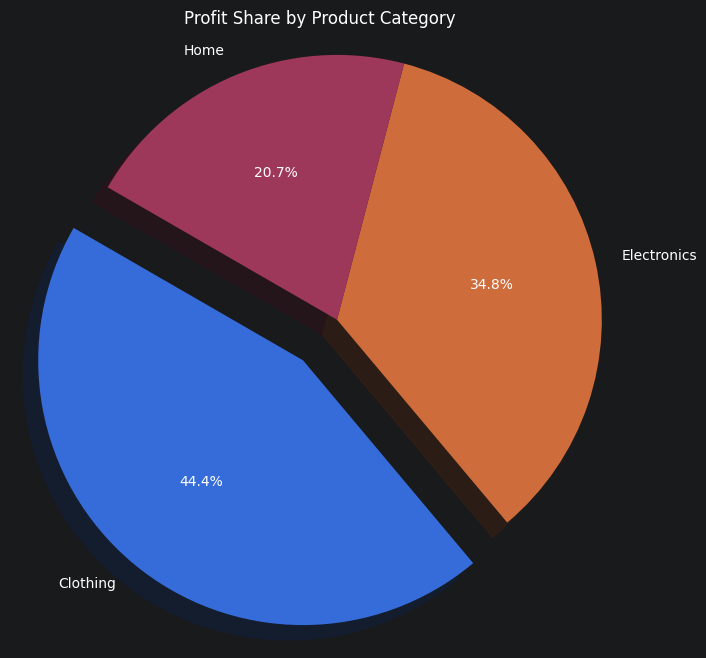

In [118]:
category_share = final_df.groupby("Category")['Total_profit'].sum()
plt.figure(figsize=(8,8))
plt.pie(category_share,labels=category_share.index,autopct='%1.1f%%', radius= 0.5,
        startangle=150,explode=[0.1, 0, 0],shadow=True)
plt.axis('equal') # Forces the chart to be a perfect circle, not an oval
plt.title('Profit Share by Product Category')
plt.show()

In [119]:
with pd.ExcelWriter('Ecommerce_Analysis_Report.xlsx') as writer:
    final_df.to_excel(writer, sheet_name='Full_Cleaned_Data', index=False)
    report.to_excel(writer, sheet_name='Profit_Summary', index=False)